# RHCR Combined Comparison Plot

将 `exp2` 指定窗口组结果与 `rhcr_compare` 结果画在同一张图（LTF风格：均值折线 + 95%CI阴影）。

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 200)


In [8]:
# ===== 配置 =====
exp2_dir = Path('/home/shiqi/masterarbeit/RHCR/exp2/rhcr_baseline_windows_20260510_130204')
cmp_dir  = Path('/home/shiqi/masterarbeit/RHCR/exp/rhcr_eval_runs/rhcr_compare_20260510_072748')

# 从 exp2 里选择多组(sim,plan)一起画
window_pairs = [(1,5), (1,10), (1,20), (5,10), (5,20)]

plot_title = 'RHCR Combined: learned + baseline(sim/plan variants)'
x_key='num_agents'
x_label='agent_num'
y_key='throughput_per_step'
fig_w=6.0
fig_h=5.0
line_w=2.0

exp2_csv = exp2_dir / 'summary.csv'
cmp_csv = cmp_dir / 'summary.csv'
assert exp2_csv.exists(), exp2_csv
assert cmp_csv.exists(), cmp_csv
print('exp2:', exp2_csv)
print('cmp :', cmp_csv)


exp2: /home/shiqi/masterarbeit/RHCR/exp2/rhcr_baseline_windows_20260510_130204/summary.csv
cmp : /home/shiqi/masterarbeit/RHCR/exp/rhcr_eval_runs/rhcr_compare_20260510_072748/summary.csv


In [9]:
d1 = pd.read_csv(exp2_csv)
d2 = pd.read_csv(cmp_csv)

for d in (d1, d2):
    d['num_agents'] = pd.to_numeric(d['num_agents'], errors='coerce').astype('Int64')
    d['seed'] = pd.to_numeric(d['seed'], errors='coerce').astype('Int64')
    d['throughput_per_step'] = pd.to_numeric(d['throughput_per_step'], errors='coerce')

exp2_parts = []
for sim_w, plan_w in window_pairs:
    sub = d1[(d1['status']=='ok') & (d1['simulation_window']==sim_w) & (d1['planning_window']==plan_w)].copy()
    sub['algorithm'] = f'baseline sim={sim_w}, plan={plan_w}'
    exp2_parts.append(sub[['algorithm','num_agents','seed','throughput_per_step']])
e = pd.concat(exp2_parts, ignore_index=True) if exp2_parts else pd.DataFrame(columns=['algorithm','num_agents','seed','throughput_per_step'])

c = d2[(d2['status']=='ok') & (d2['mode']=='learned')].copy()
c['algorithm'] = 'learned cost sim=1, plan=5'
c = c[['algorithm','num_agents','seed','throughput_per_step']]

df = pd.concat([e, c], ignore_index=True)
display(df.head(12))
print('rows:', len(df))
print('algorithms:', sorted(df['algorithm'].dropna().unique()))


,algorithm,num_agents,seed,throughput_per_step
0,"baseline sim=1, plan=5",32,10,1.250000
1,"baseline sim=1, plan=5",32,11,1.191406
2,"baseline sim=1, plan=5",32,12,1.218750
3,"baseline sim=1, plan=5",32,13,1.285156
4,"baseline sim=1, plan=5",32,14,1.269531
5,"baseline sim=1, plan=5",32,15,1.292969
6,"baseline sim=1, plan=5",32,16,1.226562
7,"baseline sim=1, plan=5",32,17,1.164062
8,"baseline sim=1, plan=5",32,18,1.234375
9,"baseline sim=1, plan=5",32,19,1.218750


rows: 360
algorithms: ['baseline sim=1, plan=10', 'baseline sim=1, plan=20', 'baseline sim=1, plan=5', 'baseline sim=5, plan=10', 'baseline sim=5, plan=20', 'learned cost sim=1, plan=5']


In [10]:
agg=(df.groupby(['algorithm',x_key])[y_key]
      .agg(['mean','std','count'])
      .reset_index())
agg['sem']=agg['std']/np.sqrt(agg['count'].clip(lower=1))
agg['ci95']=1.96*agg['sem']
display(agg.sort_values([x_key,'algorithm']))


,algorithm,num_agents,mean,std,count,sem,ci95
0,"baseline sim=1, plan=10",32,1.236328,0.033413,10,0.010566,0.020710
6,"baseline sim=1, plan=20",32,1.246094,0.022926,10,0.007250,0.014209
12,"baseline sim=1, plan=5",32,1.235156,0.040587,10,0.012835,0.025156
18,"baseline sim=5, plan=10",32,1.251953,0.019854,10,0.006278,0.012306
24,"baseline sim=5, plan=20",32,1.261719,0.024568,10,0.007769,0.015227
30,"learned cost sim=1, plan=5",32,1.198438,0.023132,10,0.007315,0.014337
1,"baseline sim=1, plan=10",64,2.303906,0.043685,10,0.013814,0.027076
7,"baseline sim=1, plan=20",64,2.322656,0.076351,10,0.024144,0.047323
13,"baseline sim=1, plan=5",64,2.262109,0.039039,10,0.012345,0.024196
19,"baseline sim=5, plan=10",64,2.331250,0.048713,10,0.015404,0.030192


Saved: /home/shiqi/masterarbeit/RHCR/exp/rhcr_eval_runs/rhcr_compare_20260510_072748/combined_exp2_windows_vs_compare.pdf


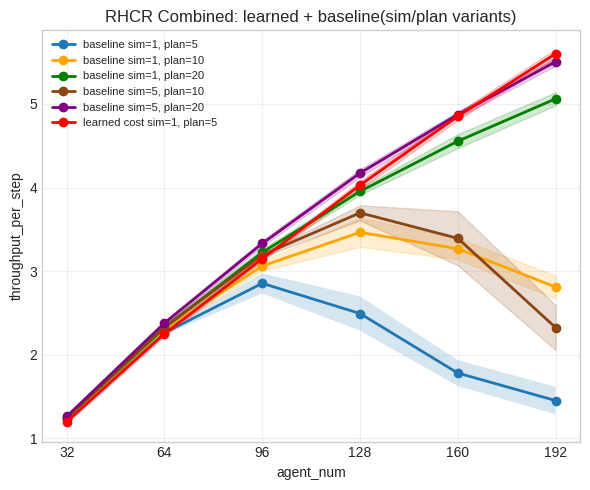

In [11]:
# LTF 风格：均值折线 + 95%CI 阴影
plt.figure(figsize=(fig_w, fig_h))

hue_order = [f'baseline sim={s}, plan={p}' for s,p in window_pairs] + ['learned cost sim=1, plan=5']
# 统一颜色映射（throughput 与 compute-time 共用）
color_map = {
    'learned cost sim=1, plan=5': 'red',
    'baseline sim=1, plan=10': 'orange',
    'baseline sim=1, plan=20': 'green',
    'baseline sim=5, plan=10': 'saddlebrown',
    'baseline sim=5, plan=20': 'purple',
}
for algo in hue_order:
    sub = agg[agg['algorithm'] == algo].sort_values(x_key)
    if len(sub) == 0:
        continue
    x = sub[x_key].tolist()
    y = sub['mean'].tolist()
    c = sub['ci95'].fillna(0).tolist()
    color = color_map.get(algo, None)
    plt.plot(x, y, marker='o', linewidth=line_w, label=str(algo), color=color)
    lo = [yy - cc for yy, cc in zip(y, c)]
    hi = [yy + cc for yy, cc in zip(y, c)]
    plt.fill_between(x, lo, hi, alpha=0.18, color=color)

plt.title(plot_title)
plt.xlabel(x_label)
plt.ylabel(y_key)
xt = sorted([int(v) for v in agg[x_key].dropna().unique().tolist()])
if xt:
    plt.xticks(xt)
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
out_pdf = cmp_dir / 'combined_exp2_windows_vs_compare.pdf'
plt.savefig(out_pdf)
print('Saved:', out_pdf)
plt.show()


,algorithm,num_agents,mean,std,count,sem,ci95
0,"baseline sim=1, plan=10",32,0.002334,0.000693,10,0.000219,0.000429
6,"baseline sim=1, plan=20",32,0.002918,0.000606,10,0.000192,0.000376
12,"baseline sim=1, plan=5",32,0.001332,0.000262,10,0.000083,0.000162
18,"baseline sim=5, plan=10",32,0.002806,0.000749,10,0.000237,0.000464
24,"baseline sim=5, plan=20",32,0.004925,0.001696,10,0.000536,0.001051
30,"learned cost sim=1, plan=5",32,0.005451,0.000671,10,0.000212,0.000416
1,"baseline sim=1, plan=10",64,0.015045,0.004990,10,0.001578,0.003093
7,"baseline sim=1, plan=20",64,0.025136,0.004801,10,0.001518,0.002976
13,"baseline sim=1, plan=5",64,0.007448,0.001389,10,0.000439,0.000861
19,"baseline sim=5, plan=10",64,0.017763,0.004818,10,0.001524,0.002986


Saved: /home/shiqi/masterarbeit/RHCR/exp/rhcr_eval_runs/rhcr_compare_20260510_072748/combined_compute_time_all_curves.pdf


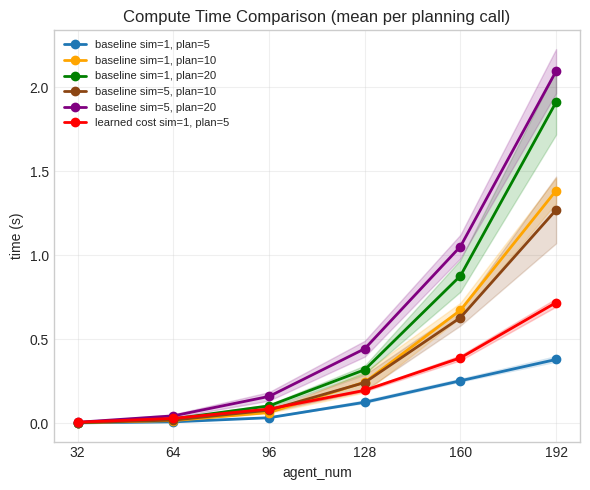

In [12]:
# 计算时间图：覆盖 throughput 图中的所有组合，颜色保持一致
import re

def parse_runlog_solver_times(log_path: Path):
    if not log_path.exists():
        return []
    times = []
    for ln in log_path.read_text(encoding='utf-8', errors='ignore').splitlines():
        if ':Succeed,' not in ln:
            continue
        try:
            payload = ln.split(':Succeed,', 1)[1]
            t = float(payload.split(',', 1)[0])
            times.append(t)
        except Exception:
            pass
    return times

exp2 = pd.read_csv(exp2_csv)
cmp  = pd.read_csv(cmp_csv)

# 与 throughput 图完全一致的算法集合
target_algos = [f'baseline sim={s}, plan={p}' for s,p in window_pairs] + ['learned cost sim=1, plan=5']

sel_exp2 = exp2[(exp2['status']=='ok')].copy()
sel_exp2['algorithm'] = sel_exp2.apply(lambda r: f"baseline sim={int(r['simulation_window'])}, plan={int(r['planning_window'])}", axis=1)
sel_exp2 = sel_exp2[sel_exp2['algorithm'].isin(target_algos)].copy()

sel_cmp = cmp[(cmp['status']=='ok') & (cmp['mode']=='learned')].copy()
sel_cmp['algorithm'] = 'learned cost sim=1, plan=5'

rows = []
for _, r in pd.concat([sel_exp2, sel_cmp], ignore_index=True).iterrows():
    run_dir = Path(str(r['run_dir']))
    ts = parse_runlog_solver_times(run_dir / 'run.log')
    if len(ts) == 0:
        continue
    rows.append({
        'algorithm': r['algorithm'],
        'num_agents': int(r['num_agents']),
        'seed': int(r['seed']),
        'mean_solver_time': float(np.mean(ts)),
    })

rt = pd.DataFrame(rows)
assert not rt.empty, 'No runtime data parsed from run.log'

agg_rt = (rt.groupby(['algorithm', 'num_agents'])['mean_solver_time']
          .agg(['mean','std','count'])
          .reset_index())
agg_rt['sem'] = agg_rt['std'] / np.sqrt(agg_rt['count'].clip(lower=1))
agg_rt['ci95'] = 1.96 * agg_rt['sem']
display(agg_rt.sort_values(['num_agents','algorithm']))

plt.figure(figsize=(fig_w, fig_h))
order = target_algos
# 与 throughput 图一致的颜色
color_map_rt = {
    'learned cost sim=1, plan=5': 'red',
    'baseline sim=1, plan=10': 'orange',
    'baseline sim=1, plan=20': 'green',
    'baseline sim=5, plan=10': 'saddlebrown',
    'baseline sim=5, plan=20': 'purple',
}
for algo in order:
    sub = agg_rt[agg_rt['algorithm']==algo].sort_values('num_agents')
    if len(sub)==0:
        continue
    x = sub['num_agents'].tolist()
    y = sub['mean'].tolist()
    c = sub['ci95'].fillna(0).tolist()
    color = color_map_rt.get(algo, None)
    plt.plot(x, y, marker='o', linewidth=line_w, label=algo, color=color)
    lo = [yy-cc for yy,cc in zip(y,c)]
    hi = [yy+cc for yy,cc in zip(y,c)]
    plt.fill_between(x, lo, hi, alpha=0.18, color=color)

plt.title('Compute Time Comparison (mean per planning call)')
plt.xlabel('agent_num')
plt.ylabel('time (s)')
xt = sorted([int(v) for v in agg_rt['num_agents'].dropna().unique().tolist()])
if xt:
    plt.xticks(xt)
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
out_pdf_rt = cmp_dir / 'combined_compute_time_all_curves.pdf'
plt.savefig(out_pdf_rt)
print('Saved:', out_pdf_rt)
plt.show()
